In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# /content/drive/MyDrive/ml/Medicaldataset.csv

In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/MLproject /Medicaldataset.csv")

BASIC EDA

In [ ]:
data.head(5)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
data.shape

(1319, 9)

In [ ]:
data.info

<bound method DataFrame.info of       Age  Gender  Heart rate  Systolic blood pressure  \
0      64       1          66                      160   
1      21       1          94                       98   
2      55       1          64                      160   
3      64       1          70                      120   
4      55       1          64                      112   
...   ...     ...         ...                      ...   
1314   44       1          94                      122   
1315   66       1          84                      125   
1316   45       1          85                      168   
1317   54       1          58                      117   
1318   51       1          94                      157   

      Diastolic blood pressure  Blood sugar  CK-MB  Troponin    Result  
0                           83        160.0   1.80     0.012  negative  
1                           46        296.0   6.75     1.060  positive  
2                           77        270.0   1.99     0.003  negative  
3                           55        270.0  13.87     0.122  positive  
4                           65        300.0   1.08     0.003  negative  
...                        ...          ...    ...       ...       ...  
1314                        67        204.0   1.63     0.006  negative  
1315                        55        149.0   1.33     0.172  positive  
1316                       104         96.0   1.24     4.250  positive  
1317                        68        443.0   5.80     0.359  positive  
1318                        79        134.0  50.89     1.770  positive  

[1319 rows x 9 columns]>

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.shape

(1319, 9)

In [ ]:
data.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [ ]:
data.isna().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0



For Data Visualization Exporatory Data Analysis

In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')

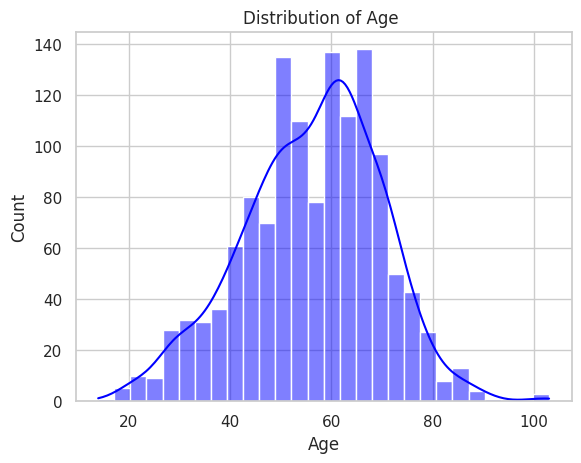

In [ ]:
sns.set_theme(style="whitegrid")
sns.histplot(data["Age"],kde=True, color="blue")
plt.title("Distribution of Age ")
plt.show()

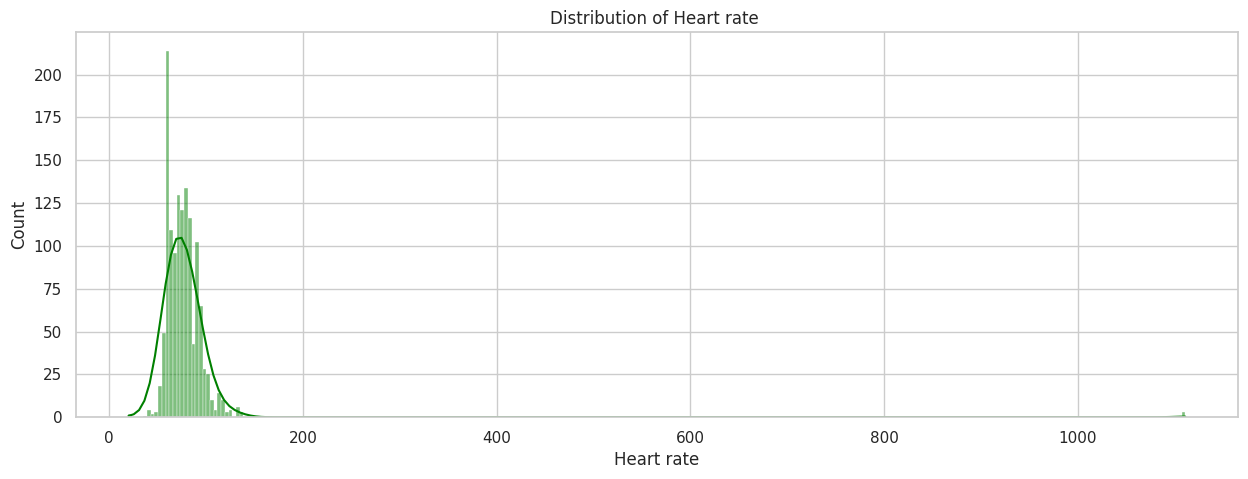

In [ ]:
plt.figure(figsize=(15,5))
sns.set_theme(style="whitegrid")
sns.histplot(data["Heart rate"],kde=True, color="green")
plt.title("Distribution of Heart rate ")
plt.show()

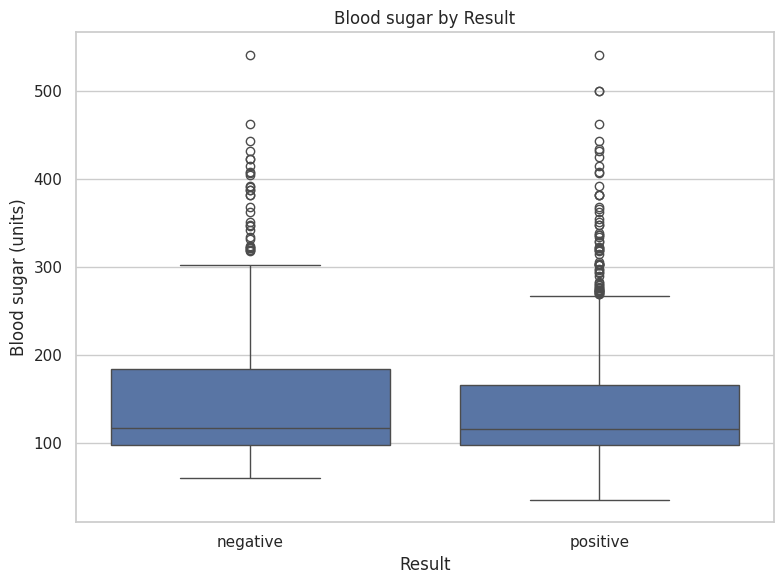

In [ ]:
# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Result', y='Blood sugar')
plt.title('Blood sugar by Result')
plt.xlabel('Result')
plt.ylabel('Blood sugar (units)')
plt.tight_layout()
plt.show()


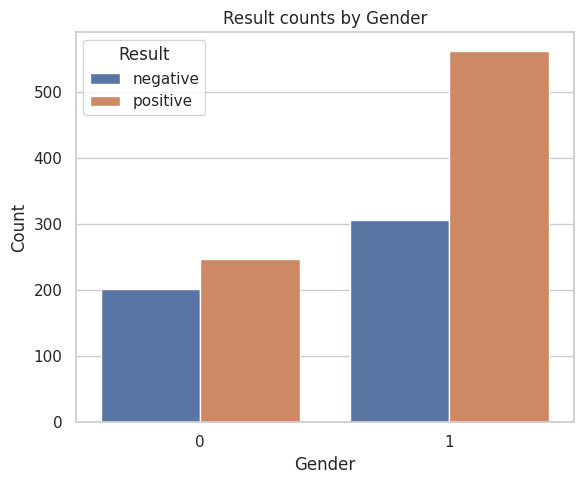

In [ ]:
# Raw counts
plt.figure(figsize=(6,5))
sns.countplot(data=data, x='Gender', hue='Result')
plt.title('Result counts by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


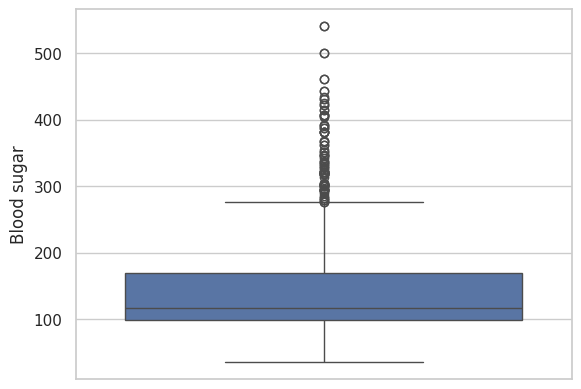

In [ ]:
sns.boxplot(data["Blood sugar"])
plt.show()

<Axes: xlabel='Gender', ylabel='Diastolic blood pressure'>

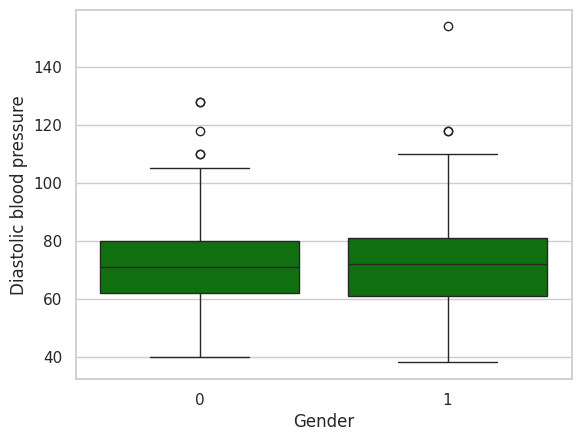

In [ ]:
sns.boxplot(data=data,x="Gender",y="Diastolic blood pressure",color="Green")

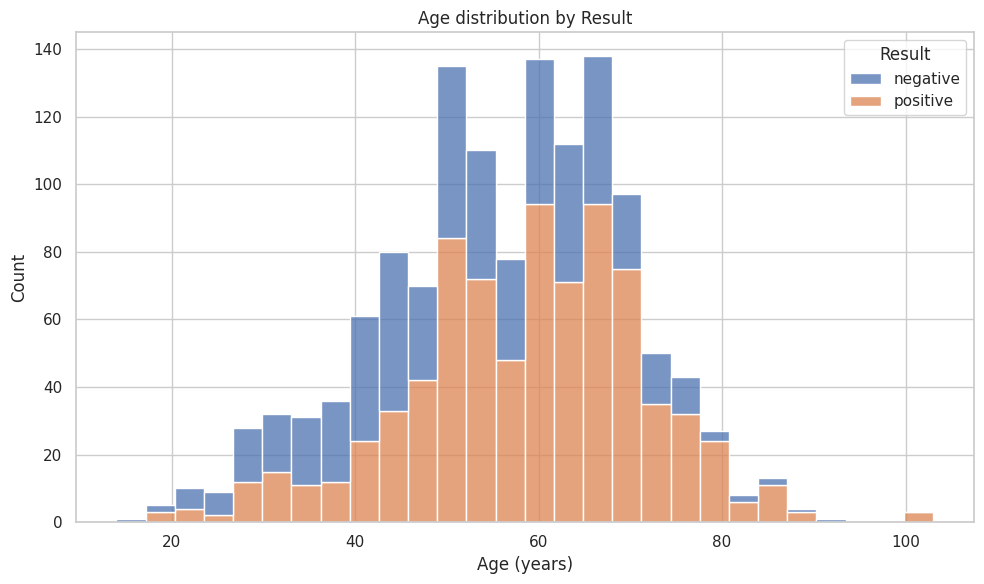

In [ ]:
# Stacked histogram
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='Age', hue='Result', multiple='stack')
plt.title('Age distribution by Result')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [ ]:
data["Age"].value_counts()

,count
Age,
60,106
70,73
50,68
63,64
65,62
...,...
91,1
100,1
88,1


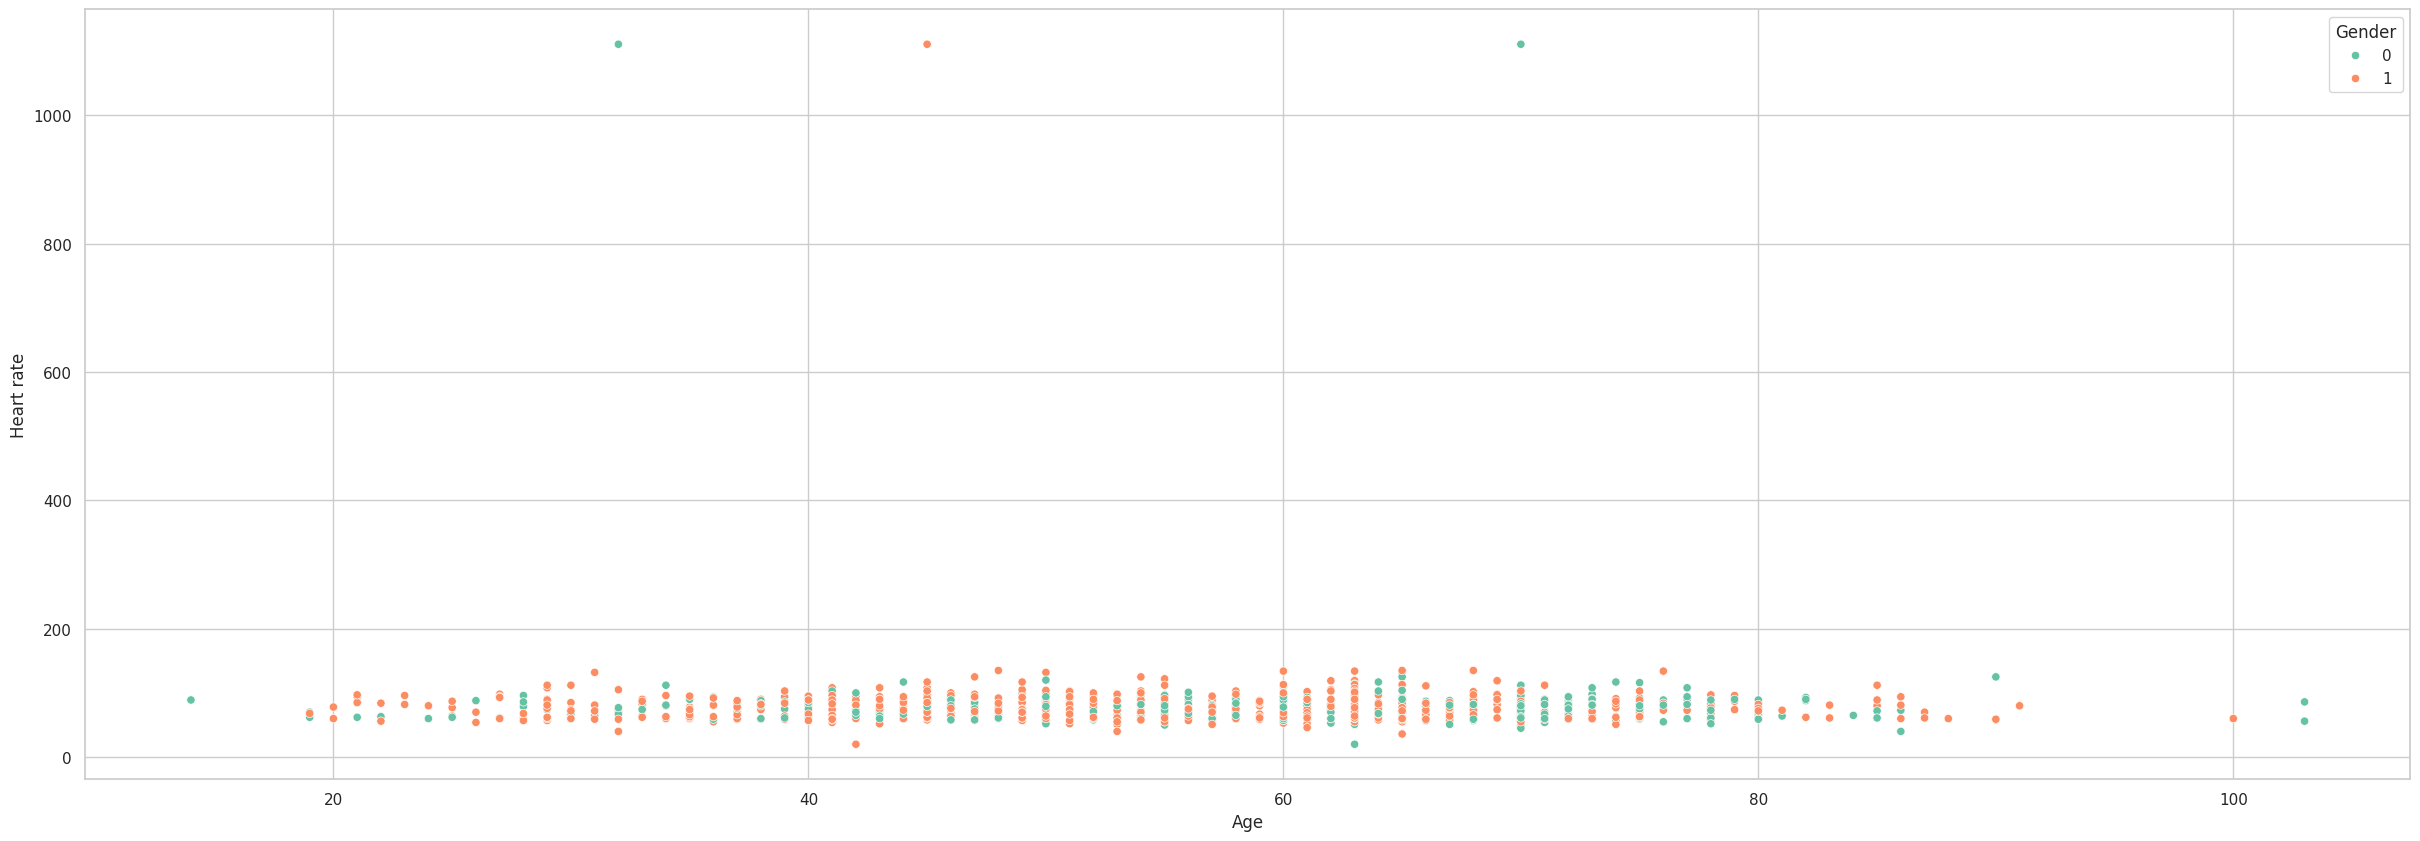

In [ ]:
plt.figure(figsize=(30,10))
sns.scatterplot(data=data,x="Age",y="Heart rate" ,hue="Gender",palette="Set2" )
plt.show()

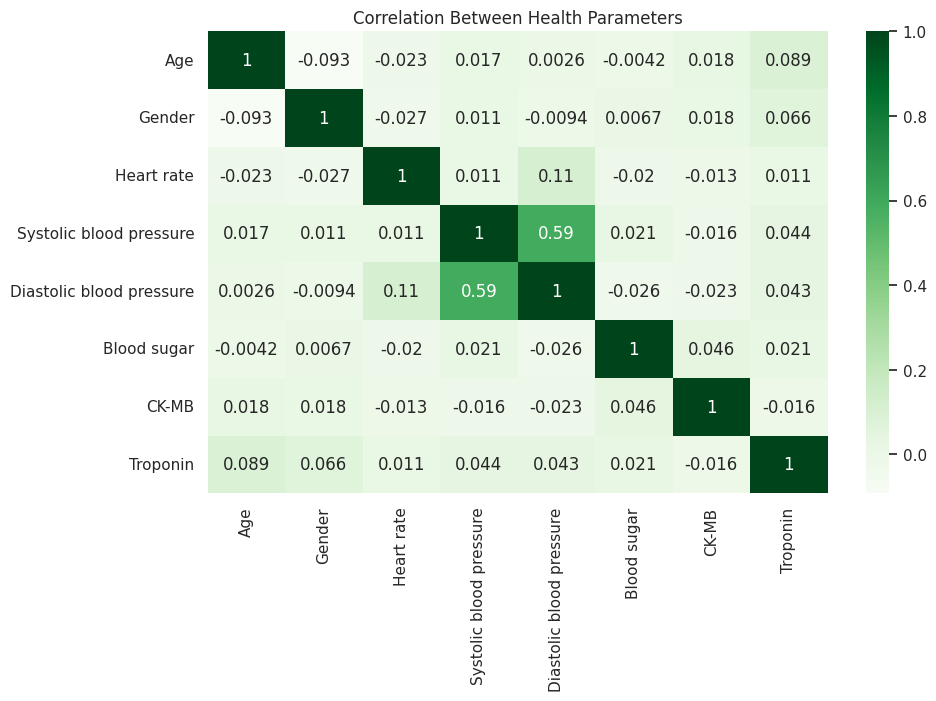

In [ ]:
plt.figure(figsize=(10,6))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Greens")
plt.title("Correlation Between Health Parameters")
plt.show()

Preprocessing of data

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["Result"]=le.fit_transform(data["Result"])

SPLITTING THE DATA

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=data.drop("Result",axis=1)
y=data["Result"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#desicion tree
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred_dtc=dt.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
print("accuracy",accuracy_score(y_test,y_pred_dtc))

accuracy 0.9810606060606061


In [ ]:
cm=confusion_matrix(y_test,y_pred_dtc)

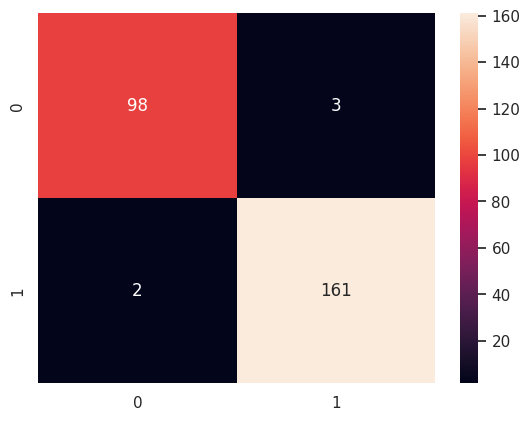

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
print("accuracy",accuracy_score(y_test,y_pred_rf))

accuracy 0.9772727272727273


In [ ]:
cm=confusion_matrix(y_test,y_pred_rf)

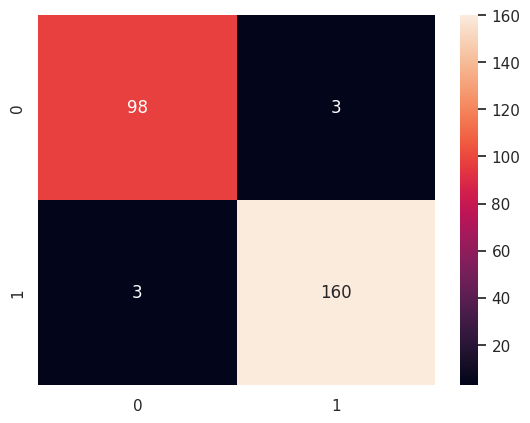

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [ ]:
#Xg boost
from xgboost import XGBClassifier
xg=XGBClassifier()
xg.fit(x_train,y_train)
y_pred_xg=xg.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
print("accuracy",accuracy_score(y_test,y_pred_xg))

accuracy 0.9810606060606061


In [ ]:
cm=confusion_matrix(y_test,y_pred_xg)

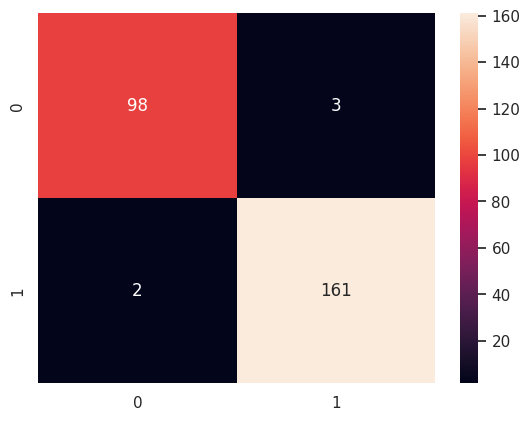

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [ ]:
importances=rf.feature_importances_
feature=x.columns

In [ ]:
fea_imp=pd.DataFrame({"Feature":feature,"Importance":importances})

In [ ]:
fea_imp.head()

,Feature,Importance
0,Age,0.049792
1,Gender,0.009704
2,Heart rate,0.016208
3,Systolic blood pressure,0.023226
4,Diastolic blood pressure,0.021728


In [ ]:
fea_imp=fea_imp.sort_values(by="Importance",ascending=False)

In [ ]:
fea_imp.head()

,Feature,Importance
7,Troponin,0.593260
6,CK-MB,0.262091
0,Age,0.049792
5,Blood sugar,0.023989
3,Systolic blood pressure,0.023226


In [ ]:
fea_imp=fea_imp.sort_values(by="Importance",ascending=False).head(5)

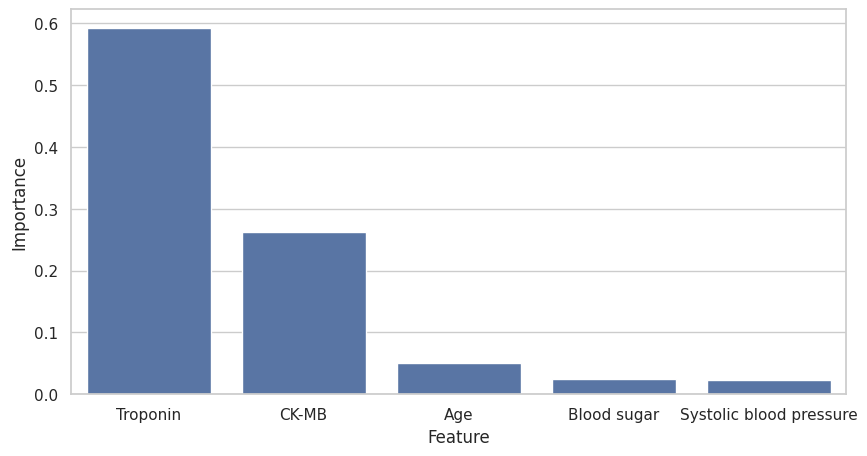

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=fea_imp,x="Feature",y="Importance")
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(xg,"heartattack_type_dtc.pkl")
['heartattack_type_dtc.pk']

['heartattack_type_dtc.pk']

In [ ]:
from google.colab import files
files.download("heartattack_type_dtc.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
uploaded=files.upload()

Saving heartattack_type_dtc.pkl to heartattack_type_dtc (1).pkl


In [ ]:
model=joblib.load("heartattack_type_dtc.pkl")